In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import cv2, os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.utils import shuffle

In [3]:
DATASET_DIR = '/content/drive/MyDrive/data'
class_names = ['23-50277-1', '23-50254-1', '22-48133-2_', '22-48021-2', '22-46887-1']

IMG_SIZE = 128
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
)

In [4]:
def load_faces(base_dir):
    X, y = [], []

    for label, person in enumerate(class_names):
        person_dir = os.path.join(base_dir, person)

        for img_name in os.listdir(person_dir):
            img_path = os.path.join(person_dir, img_name)
            img = cv2.imread(img_path)

            if img is None:
                continue

            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            faces = face_cascade.detectMultiScale(gray, 1.3, 5)

            if len(faces) == 0:
                continue

            x, y_, w, h = faces[0]
            face = img[y_:y_+h, x:x+w]
            face = cv2.resize(face, (IMG_SIZE, IMG_SIZE))

            X.append(face)
            y.append(label)

    return np.array(X), np.array(y)


In [5]:
X, Y = load_faces(DATASET_DIR)

print("Dataset Shape:", X.shape, Y.shape)

X, Y = shuffle(X, Y, random_state=42)

Dataset Shape: (104, 128, 128, 3) (104,)


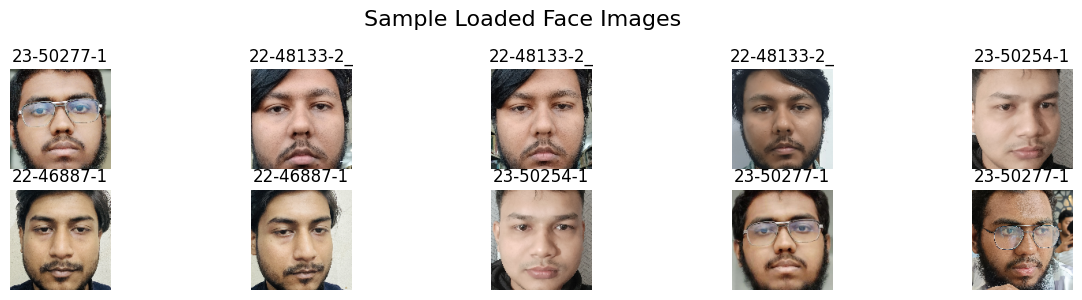

In [6]:
plt.figure(figsize=(15,6))
num_images = min(10, len(X))

for i in range(num_images):
    plt.subplot(4, 5, i+1)
    plt.imshow(cv2.cvtColor(X[i], cv2.COLOR_BGR2RGB))
    plt.title(class_names[Y[i]])
    plt.axis('off')

plt.suptitle("Sample Loaded Face Images", fontsize=16)
plt.show()

X = X.astype('float32') / 255.0

In [7]:
model = keras.Sequential([
    keras.Input(shape=(128,128,3)),

    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D(),

    layers.Conv2D(256, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D(),

    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(5, activation='softmax')
])


In [8]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

h = model.fit(X, Y,epochs=30,batch_size=16,validation_split=0.2)


Epoch 1/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 11s 929ms/step - accuracy: 0.2032 - loss: 1.6244 - val_accuracy: 0.3333 - val_loss: 1.5933
Epoch 2/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.2938 - loss: 1.5812 - val_accuracy: 0.3333 - val_loss: 1.6373
Epoch 3/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.2427 - loss: 1.6637 - val_accuracy: 0.3333 - val_loss: 1.5952
Epoch 4/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.2596 - loss: 1.5928 - val_accuracy: 0.3333 - val_loss: 1.5838
Epoch 5/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.2721 - loss: 1.5850 - val_accuracy: 0.3333 - val_loss: 1.5667
Epoch 6/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.2993 - loss: 1.5664 - val_accuracy: 0.3333 - val_loss: 1.5870
Epoch 7/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.2645 - loss: 1.5725 - val_accuracy: 0.3333 - val_loss: 1.5938
Epoch 8/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.2854 - loss: 1.5429 - val_accuracy: 0.3333 - val_loss: 1.562

In [9]:
model.save('AttendanceSystem.keras')
print("Model Saved Successfully!")

Model Saved Successfully!
